## 필요한 것들 다 끌고와 !

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import seaborn as sns
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve
from matplotlib.patches import Arc


import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import r2_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [2]:
import matplotlib.font_manager as fm
fm.findSystemFonts(fontpaths=None, fontext='ttf')
import matplotlib
import matplotlib.font_manager as fm

#Mac Os font settint
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

## Given data 가져오고 전처리 때려 !

In [3]:

df_raw=pd.read_csv('./B1_종합실습2_전처리데이터(Tree).csv')
df_raw.head()

,scale,pt_thick,pt_width,hsb,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_temp,descaling_count,...,class_code_BV,class_code_CCS,class_code_Common,class_code_DNV,class_code_GL,class_code_JS,class_code_KR,class_code_KS,class_code_LR,class_code_NK
0,0,32,3700,1,1144,116,1133,59,934,2,...,0,0,0,0,0,0,0,0,0,0
1,0,32,3700,1,1144,122,1135,53,937,2,...,0,0,0,0,0,0,0,0,0,0
2,0,33,3600,1,1129,116,1121,55,889,2,...,0,0,0,1,0,0,0,0,0,0
3,0,33,3600,1,1152,125,1127,68,885,2,...,0,0,0,1,0,0,0,0,0,0
4,0,38,3100,1,1140,134,1128,48,873,2,...,1,0,0,0,0,0,0,0,0,0


In [4]:
# 목표변수, 설명변수 데이터 지정
df_raw_y = df_raw['scale']
df_raw_x = df_raw.drop('scale', axis = 1, inplace = False)
df_raw_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   pt_thick                   1000 non-null   int64
 1   pt_width                   1000 non-null   int64
 2   hsb                        1000 non-null   int64
 3   fur_heat_temp              1000 non-null   int64
 4   fur_heat_time              1000 non-null   int64
 5   fur_soak_temp              1000 non-null   int64
 6   fur_soak_time              1000 non-null   int64
 7   rolling_temp               1000 non-null   int64
 8   descaling_count            1000 non-null   int64
 9   steel_kind_C               1000 non-null   int64
 10  steel_kind_T               1000 non-null   int64
 11  fur_no_1호기                 1000 non-null   int64
 12  fur_no_2호기                 1000 non-null   int64
 13  fur_no_3호기                 1000 non-null   int64
 14  fur_input_row_1열         

In [5]:
df_raw

,scale,pt_thick,pt_width,hsb,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_temp,descaling_count,...,class_code_BV,class_code_CCS,class_code_Common,class_code_DNV,class_code_GL,class_code_JS,class_code_KR,class_code_KS,class_code_LR,class_code_NK
0,0,32,3700,1,1144,116,1133,59,934,2,...,0,0,0,0,0,0,0,0,0,0
1,0,32,3700,1,1144,122,1135,53,937,2,...,0,0,0,0,0,0,0,0,0,0
2,0,33,3600,1,1129,116,1121,55,889,2,...,0,0,0,1,0,0,0,0,0,0
3,0,33,3600,1,1152,125,1127,68,885,2,...,0,0,0,1,0,0,0,0,0,0
4,0,38,3100,1,1140,134,1128,48,873,2,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,19,3400,1,1142,55,1151,86,948,3,...,1,0,0,0,0,0,0,0,0,0
996,0,19,3400,1,1142,55,1151,86,948,3,...,0,0,0,0,0,0,0,0,1,0
997,0,17,3400,1,1169,65,1163,77,948,3,...,0,0,0,0,0,0,0,0,0,0
998,0,17,3400,1,1169,65,1163,77,948,3,...,0,0,0,1,0,0,0,0,0,0


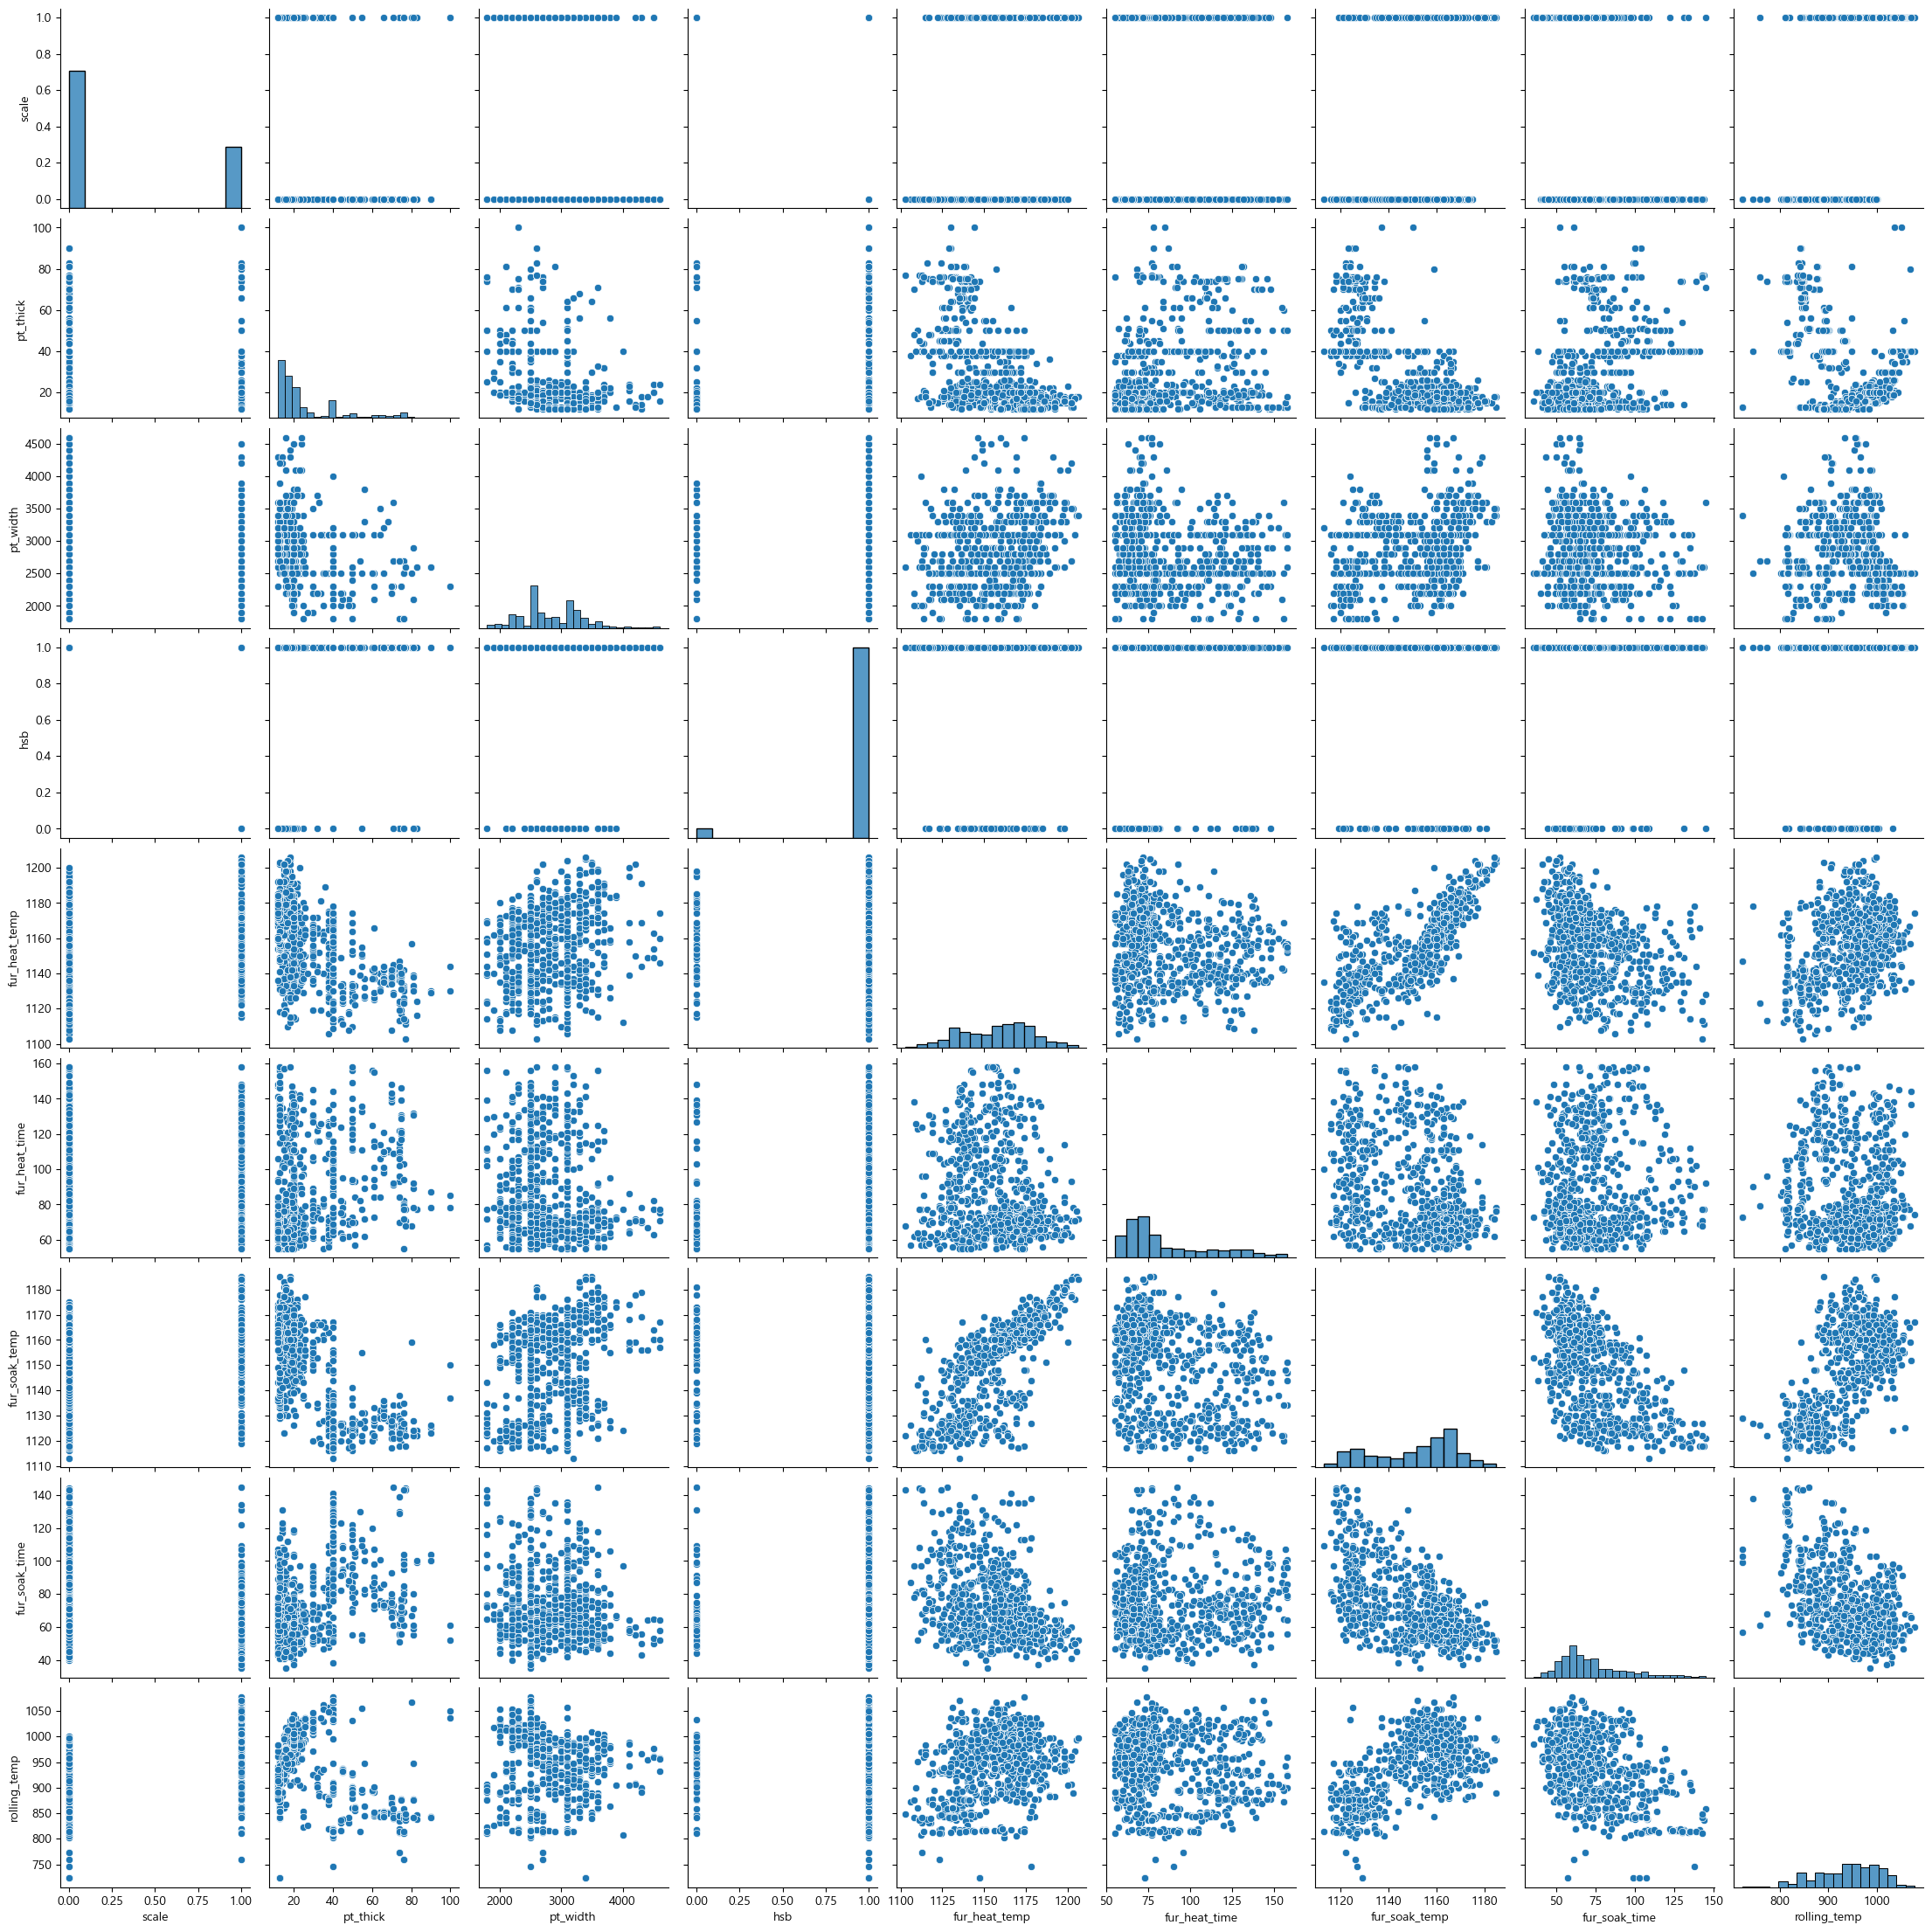

In [6]:
# pairplot
sns.pairplot(df_raw.iloc[:,:9])
plt.show()

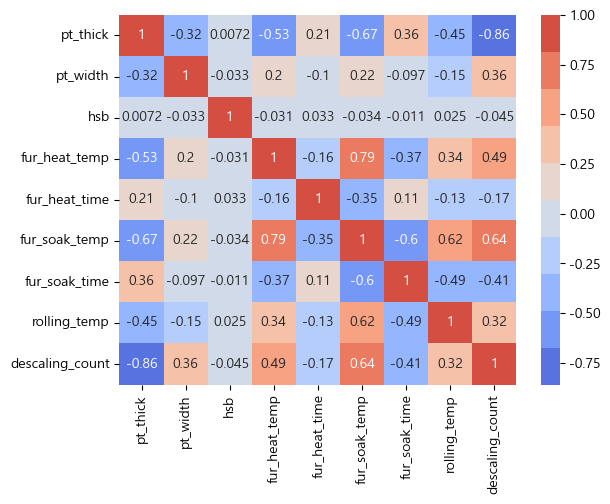

In [7]:
# x 변수들과의 상관계수 그래프 : heatmap
corr_list = df_raw_x.iloc[:,:9].corr()
sns.heatmap(corr_list, cmap = sns.color_palette("coolwarm", 10), annot = True)
plt.show()


In [8]:
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y, test_size = 0.4, random_state = 1986)
print("train data X size : {}".format(df_train_x.shape))
print("train data Y size : {}".format(df_train_y.shape))
print("test data X size : {}".format(df_test_x.shape))
print("test data Y size : {}".format(df_test_y.shape))

train data X size : (600, 35)
train data Y size : (600,)
test data X size : (400, 35)
test data Y size : (400,)


# 분류 모델 고고

## -Random Forest

### 트리 수 조정 

In [9]:

rf_train_accuracy = []
rf_test_accuracy = []

param_n_estimator = [n * 1 for n in range(1,41)]

for n_esti in param_n_estimator:
    rf=RandomForestClassifier(n_estimators = n_esti, random_state = 1986)
    rf.fit(df_train_x, df_train_y)  # 훈련용 데이터 줘버려~
    rf_train_accuracy.append(rf.score(df_train_x, df_train_y))
    rf_test_accuracy.append(rf.score(df_test_x, df_test_y))


# Random Forest n-estimator 저장할 리스트 만들어!
rf_accuracy = pd.DataFrame()
rf_accuracy['n_estimator'] = param_n_estimator
rf_accuracy['Train accuracy'] = rf_train_accuracy
rf_accuracy['Test accuracy'] = rf_test_accuracy
rf_accuracy['Difference']=rf_accuracy['Train accuracy'] - rf_accuracy['Test accuracy']

rf_accuracy.round(3)

,n_estimator,Train accuracy,Test accuracy,Difference
0,1,0.952,0.828,0.124
1,2,0.953,0.898,0.056
2,3,0.980,0.880,0.100
3,4,0.975,0.898,0.078
4,5,0.985,0.902,0.083
5,6,0.982,0.908,0.074
6,7,0.987,0.920,0.067
7,8,0.987,0.938,0.049
8,9,0.993,0.935,0.058
9,10,0.992,0.932,0.059


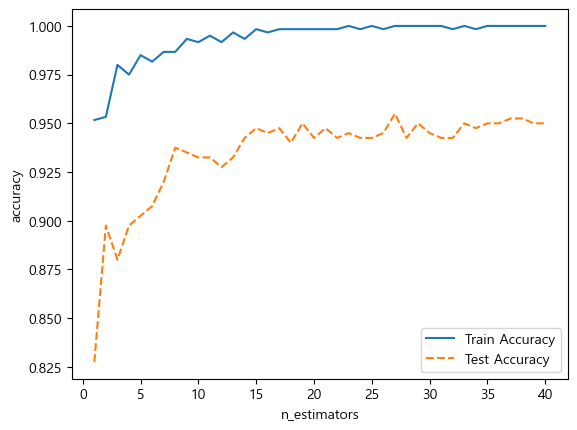

In [10]:
# 그래프로 확인
plt.plot(param_n_estimator, rf_train_accuracy, linestyle = '-', label = 'Train Accuracy')
plt.plot(param_n_estimator, rf_test_accuracy, linestyle = '--', label = 'Test Accuracy')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.legend()
plt.show()

##### ->> n_estimator 8로 하자

### 과대적합 -> 평가지표 확인 필요 : confusion matrix

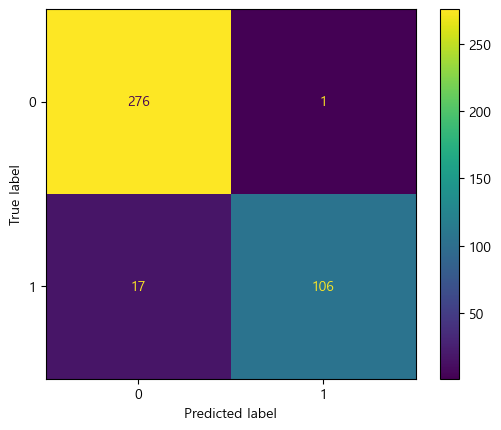

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       277
           1       0.99      0.86      0.92       123

    accuracy                           0.95       400
   macro avg       0.97      0.93      0.95       400
weighted avg       0.96      0.95      0.95       400



In [11]:
# confusion matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

best_rf = RandomForestClassifier(n_estimators=100, random_state=1986)
best_rf.fit(df_train_x, df_train_y)

y_pred = best_rf.predict(df_test_x)


cm = confusion_matrix(df_test_y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# Classification Report
print(classification_report(df_test_y, y_pred))

0.11166666666666669


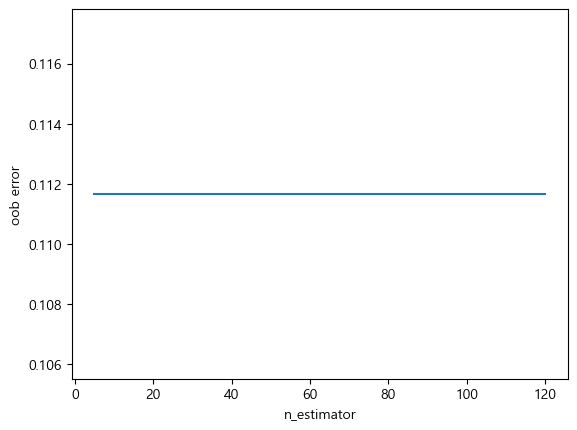

In [12]:
## OOB 확인하자 
oob_error=[]

for n_esti in range(5,121):
    rf=RandomForestClassifier(n_estimators=8, oob_score=True, random_state=1986)
    rf.fit(df_train_x, df_train_y)
    oob_error.append(1-rf.oob_score_) 

plt.plot(range(5,121), oob_error)
plt.ylabel('oob error')
plt.xlabel('n_estimator')

print(np.min(oob_error))

### leaf 데이터 수 조정 

In [13]:
#위에서 구한 결정트리의 수 estimator를 8으로 설정 후 다른 param인 leaf_sample 변경하면서 모델의 설명력을 확인
train_score=[]; test_score=[]
para_leaf=[n_leaf for n_leaf in range(1, 21)]

for v_min_samples_leaf in para_leaf:
    rf=RandomForestClassifier(random_state=1986, n_estimators=8, min_samples_leaf=v_min_samples_leaf)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))

df_score_leaf=pd.DataFrame()
df_score_leaf['MinSamplesLeaf']=para_leaf
df_score_leaf['TrainScore']=train_score
df_score_leaf['TestScore']=test_score
df_score_leaf['Difference']=df_score_leaf['TrainScore']-df_score_leaf['TestScore']

In [14]:
# 스코어 확인
df_score_leaf.round(3)

,MinSamplesLeaf,TrainScore,TestScore,Difference
0,1,0.987,0.938,0.049
1,2,0.957,0.900,0.057
2,3,0.947,0.910,0.037
3,4,0.933,0.908,0.026
4,5,0.923,0.892,0.031
5,6,0.923,0.882,0.041
6,7,0.932,0.915,0.017
7,8,0.922,0.888,0.034
8,9,0.918,0.900,0.018
9,10,0.907,0.892,0.014


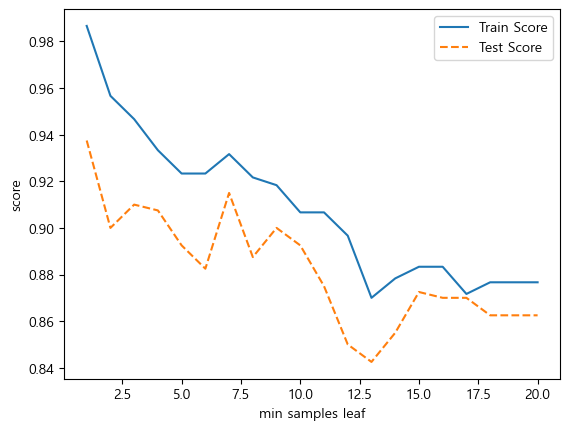

In [15]:
#그래프 확인
plt.plot(para_leaf, train_score, linestyle='-', label='Train Score')
plt.plot(para_leaf, test_score, linestyle='--', label='Test Score')
plt.ylabel('score')
plt.xlabel('min samples leaf')
plt.legend()
plt.show()

##### - train과 test의 차이가 가장 작으면서 충분한 정확도를 확보한 leaf data 17개로 결정 : 복잡도 감소 및 시간과 비용 고려

### split 데이터 수 조정 

In [16]:
# split data 수 변경
train_score=[]; test_score=[]
para_split=[n_split for n_split in range(34, 71)]

for v_min_samples_split in para_split:
    rf=RandomForestClassifier(random_state=1986, n_estimators=8, min_samples_leaf=17, min_samples_split=v_min_samples_split)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))
    
df_score_split=pd.DataFrame()
df_score_split['MinSamplesSplit']=para_split
df_score_split['TrainScore']=train_score
df_score_split['TestScore']=test_score
df_score_split['Difference']=df_score_split['TrainScore']-df_score_split['TestScore']

In [17]:
df_score_split.round(3)

,MinSamplesSplit,TrainScore,TestScore,Difference
0,34,0.872,0.870,0.002
1,35,0.872,0.862,0.009
2,36,0.875,0.860,0.015
3,37,0.880,0.860,0.020
4,38,0.880,0.860,0.020
5,39,0.880,0.860,0.020
6,40,0.877,0.862,0.014
7,41,0.880,0.865,0.015
8,42,0.882,0.855,0.027
9,43,0.877,0.862,0.014


In [18]:
np.min(df_score_split.round(3))

MinSamplesSplit    34.000
TrainScore          0.870
TestScore           0.855
Difference          0.002
dtype: float64

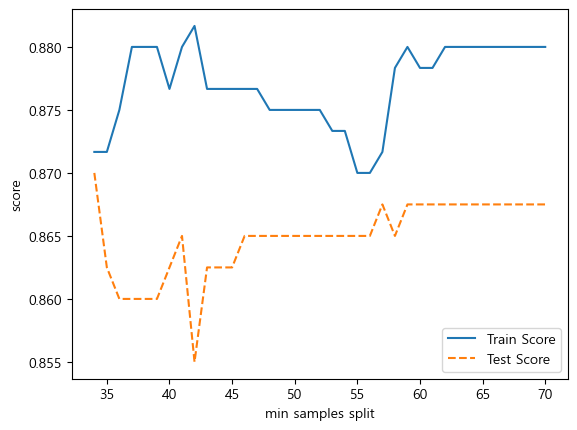

In [19]:
# 그래프 확인
plt.plot(para_split, train_score, linestyle='-', label='Train Score')
plt.plot(para_split, test_score, linestyle='--', label='Test Score')
plt.ylabel('score')
plt.xlabel('min samples split')
plt.legend()
plt.show()

##### - split samples의 수는 과적합의 문제와 학습시간 및 비용을 고려 : split sample 57개로 결정

### depth 수 조정 

In [20]:
# depth 변경
train_score=[]; test_score=[]
para_depth=[depth for depth in range(1, 21)]

for v_max_depth in para_depth:
    rf=RandomForestClassifier(random_state=1986, n_estimators=8, min_samples_leaf=17, min_samples_split=57, max_depth=v_max_depth)
    rf.fit(df_train_x, df_train_y)
    train_score.append(rf.score(df_train_x, df_train_y))
    test_score.append(rf.score(df_test_x, df_test_y))
    
df_score_depth=pd.DataFrame()
df_score_depth['Depth']=para_depth
df_score_depth['TrainScore']=train_score
df_score_depth['TestScore']=test_score
df_score_depth['Difference']=df_score_depth['TrainScore']-df_score_depth['TestScore']

df_score_depth.round(3)

,Depth,TrainScore,TestScore,Difference
0,1,0.688,0.692,-0.004
1,2,0.863,0.842,0.021
2,3,0.863,0.842,0.021
3,4,0.882,0.860,0.022
4,5,0.868,0.865,0.003
5,6,0.872,0.868,0.004
6,7,0.872,0.868,0.004
7,8,0.872,0.868,0.004
8,9,0.872,0.868,0.004
9,10,0.872,0.868,0.004


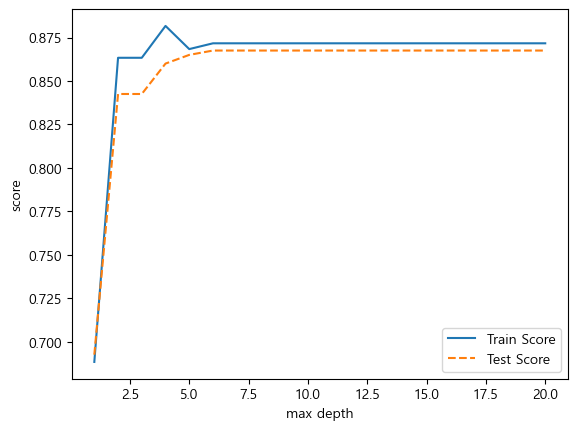

In [21]:
# 그래프 확인
plt.plot(para_depth, train_score, linestyle='-', label='Train Score')
plt.plot(para_depth, test_score, linestyle='--', label='Test Score')
plt.ylabel('score')
plt.xlabel('max depth')
plt.legend()
plt.show()

##### - max_depth : 5개로 결정

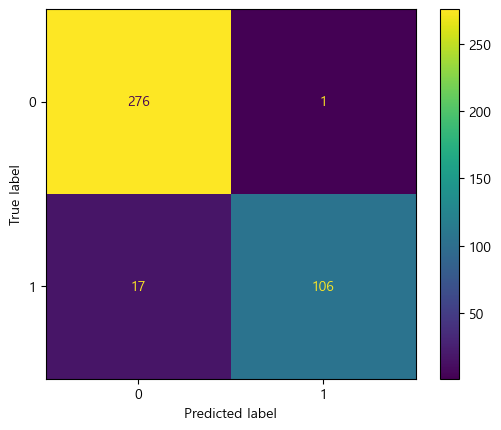

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       277
           1       0.99      0.86      0.92       123

    accuracy                           0.95       400
   macro avg       0.97      0.93      0.95       400
weighted avg       0.96      0.95      0.95       400



In [22]:
# 최종 모델 생성
rf_final = RandomForestClassifier(random_state=1986, n_estimators=8, min_samples_leaf=17, min_samples_split=57, max_depth=5)
rf_final.fit(df_train_x, df_train_y)

# 평가
y_pred_train = rf_final.predict(df_train_x)
y_prob_train = rf_final.predict_proba(df_train_x)[:,1]
y_pred_test = rf_final.predict(df_test_x)
y_prob_test = rf_final.predict_proba(df_test_x)[:,1]


# confusion matrix
cm = confusion_matrix(df_test_y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(classification_report(df_test_y, y_pred))


In [23]:
train_accuracy = rf_final.score(df_train_x, df_train_y)
print(f"Train Accuracy: {train_accuracy:.4f}")

# 테스트 데이터 정확도
test_accuracy = rf_final.score(df_test_x, df_test_y)
print(f"Test Accuracy: {test_accuracy:.4f}")

Train Accuracy: 0.8683
Test Accuracy: 0.8650


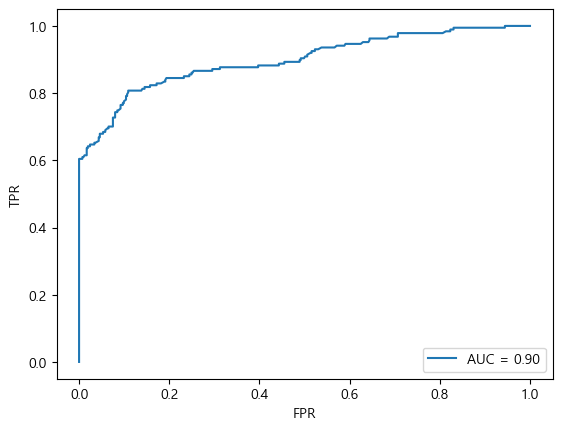

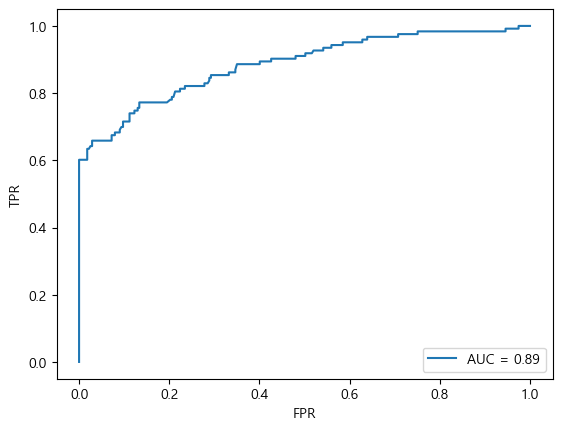

             RF-train   RF-test   RF-diff
Accuracy     0.868333  0.865000  0.003333
Precision    0.942623  1.000000 -0.057377
Recall       0.614973  0.560976  0.053998
F1_score     0.744337  0.718750  0.025587
Specificity  0.983051  1.000000 -0.016949


In [25]:
from sklearn.metrics import roc_curve, auc

def print_metric(y_true, y_pred, y_pred_proba, data_name): # 실제값, 예측값, ROC 커브이미지 저장이름 ex)RF-train
    cm = confusion_matrix(y_true, y_pred)
    TP = cm[1][1]
    TN = cm[0][0]
    FP = cm[0][1]
    FN = cm[1][0]

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP)
    recall = TP / (TP + FN)
    f1_score = 2 * (precision * recall) / (precision + recall)
    specificity = TN / (TN + FP)

    metric_list = [accuracy, precision,recall, f1_score, specificity]
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label= "AUC = %0.2f"% roc_auc)
    plt.legend(loc="lower right")
    plt.ylabel("TPR"); plt.xlabel("FPR") 
    plt.savefig(data_name+"_roc_curve.png")
    plt.show()
    
    return pd.DataFrame(metric_list, index=['Accuracy', 'Precision', 'Recall', 'F1_score', 'Specificity'])
    
metric_df_first = pd.DataFrame(index=['Accuracy', 'Precision', 'Recall', 'F1_score', 'Specificity'])
metric_list_train = print_metric(df_train_y, y_pred_train,y_prob_train, "RF-train")
metric_list_test = print_metric(df_test_y, y_pred_test, y_prob_test, "RF-test")

metric_df_first['RF-train'] = metric_list_train
metric_df_first['RF-test'] = metric_list_test
metric_df_first['RF-diff'] = metric_df_first['RF-train']-metric_df_first['RF-test']
print(metric_df_first)


## -Gradient Boosting

In [62]:
gb_uncustomized = GradientBoostingClassifier(random_state=1986)
gb_uncustomized.fit(df_train_x, df_train_y)

print('Score on training set: {:.3f}'.format(gb_uncustomized.score(df_train_x, df_train_y)))
print('Score on test set: {:.3f}'.format(gb_uncustomized.score(df_test_x, df_test_y)))

Score on training set: 0.978
Score on test set: 0.958


In [63]:
# learning rate 변경하면서 모델의 설명력 확인
train_score=[]; test_score=[]
para_n=[n * 5 for n in range(1, 21)]

for v_estimators in para_n:
    gb=GradientBoostingClassifier(random_state=1986, n_estimators=v_estimators)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))
    
df_score_n=pd.DataFrame()
df_score_n['LearningRate']=para_n
df_score_n['TrainScore']=train_score
df_score_n['TestScore']=test_score
df_score_n['Difference']=df_score_n['TrainScore']-df_score_n['TestScore']

df_score_n.round(3)

,LearningRate,TrainScore,TestScore,Difference
0,5,0.960,0.960,0.000
1,10,0.960,0.960,0.000
2,15,0.960,0.960,0.000
3,20,0.960,0.960,0.000
4,25,0.960,0.960,0.000
5,30,0.962,0.960,0.002
6,35,0.962,0.958,0.004
7,40,0.962,0.958,0.004
8,45,0.963,0.958,0.006
9,50,0.965,0.958,0.007


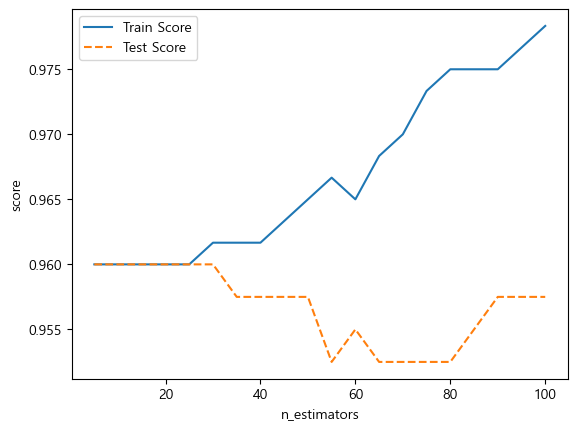

In [64]:
# learning rate별 정확도 그래프 확인
plt.plot(para_n, train_score, linestyle='-', label='Train Score')
plt.plot(para_n, test_score, linestyle='--', label='Test Score')
plt.ylabel('score')
plt.xlabel('n_estimators')
plt.legend()
plt.show()

#### n_estimaors = 30

In [65]:
# learning rate 변경하면서 모델의 설명력 확인
train_score=[]; test_score=[]
para_lr=[lr*0.01 for lr in range(1, 100, 10)]

for v_learning_rate in para_lr:
    gb=GradientBoostingClassifier(random_state=1986, n_estimators= 30, learning_rate=v_learning_rate)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))
    
df_score_lr=pd.DataFrame()
df_score_lr['LearningRate']=para_lr
df_score_lr['TrainScore']=train_score
df_score_lr['TestScore']=test_score
df_score_lr['Difference']=df_score_lr['TrainScore']-df_score_lr['TestScore']

df_score_lr.round(3)

,LearningRate,TrainScore,TestScore,Difference
0,0.01,0.688,0.692,-0.004
1,0.11,0.962,0.960,0.002
2,0.21,0.973,0.950,0.023
3,0.31,0.993,0.948,0.046
4,0.41,0.997,0.925,0.072
5,0.51,1.000,0.922,0.078
6,0.61,0.998,0.928,0.071
7,0.71,1.000,0.925,0.075
8,0.81,1.000,0.922,0.078
9,0.91,1.000,0.932,0.068


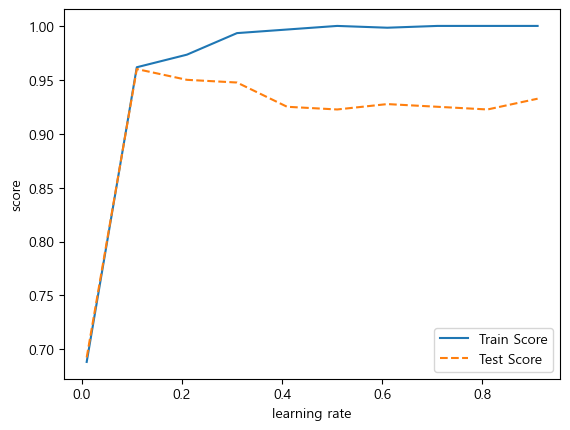

In [66]:
# learning rate별 정확도 그래프 확인
plt.plot(para_lr, train_score, linestyle='-', label='Train Score')
plt.plot(para_lr, test_score, linestyle='--', label='Test Score')
plt.ylabel('score')
plt.xlabel('learning rate')
plt.legend()
plt.show()

#####  Learning-rate = 0.11

In [68]:
# learning rate 변경하면서 모델의 설명력 확인
train_score=[]; test_score=[]
para_depth=[d for d in range(3, 16)]

for v_depth in para_depth:
    gb=GradientBoostingClassifier(random_state=1986, n_estimators= 30, learning_rate=0.11, max_depth=v_depth)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))
    
df_score_d=pd.DataFrame()
df_score_d['max_depth']=para_depth
df_score_d['TrainScore']=train_score
df_score_d['TestScore']=test_score
df_score_d['Difference']=df_score_d['TrainScore']-df_score_d['TestScore']

df_score_d.round(3)

,max_depth,TrainScore,TestScore,Difference
0,3,0.962,0.960,0.002
1,4,0.962,0.960,0.002
2,5,0.970,0.960,0.010
3,6,0.977,0.955,0.022
4,7,0.985,0.955,0.030
5,8,0.988,0.960,0.028
6,9,0.998,0.958,0.041
7,10,1.000,0.955,0.045
8,11,1.000,0.955,0.045
9,12,1.000,0.952,0.047


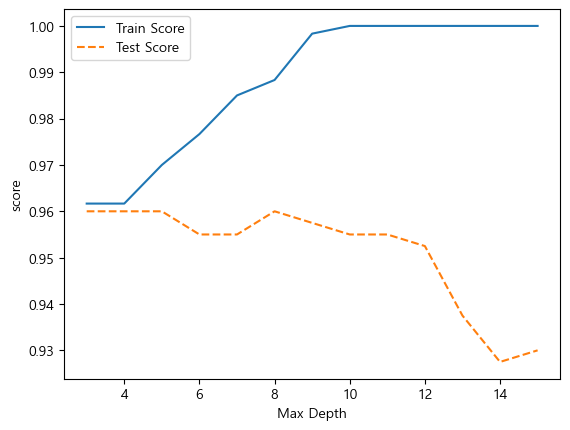

In [69]:
# learning rate별 정확도 그래프 확인
plt.plot(para_depth, train_score, linestyle='-', label='Train Score')
plt.plot(para_depth, test_score, linestyle='--', label='Test Score')
plt.ylabel('score')
plt.xlabel('Max Depth')
plt.legend()
plt.show()

#### max_depth = 8

In [73]:
# learning rate 변경하면서 모델의 설명력 확인
train_score=[]; test_score=[]
para_split=[s*10 for s in range(2,15)]

for v_split in para_split:
    gb=GradientBoostingClassifier(random_state=1986, n_estimators= 30, learning_rate=0.11, max_depth=8, min_samples_split=v_split)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))
    
df_score_s=pd.DataFrame()
df_score_s['min_samples_split']=para_split
df_score_s['TrainScore']=train_score
df_score_s['TestScore']=test_score
df_score_s['Difference']=df_score_s['TrainScore']-df_score_s['TestScore']

df_score_s.round(3)

,min_samples_split,TrainScore,TestScore,Difference
0,20,0.975,0.958,0.017
1,30,0.973,0.952,0.021
2,40,0.975,0.955,0.020
3,50,0.972,0.952,0.019
4,60,0.972,0.952,0.019
5,70,0.968,0.955,0.013
6,80,0.968,0.955,0.013
7,90,0.967,0.958,0.009
8,100,0.972,0.958,0.014
9,110,0.963,0.960,0.003


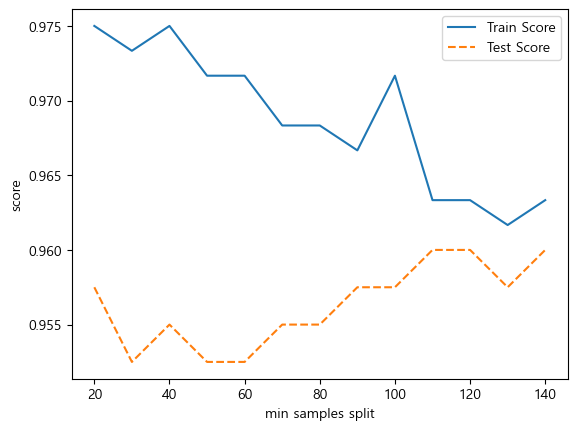

In [74]:
# learning rate별 정확도 그래프 확인
plt.plot(para_split, train_score, linestyle='-', label='Train Score')
plt.plot(para_split, test_score, linestyle='--', label='Test Score')
plt.ylabel('score')
plt.xlabel('min samples split')
plt.legend()
plt.show()

#### split = 110

In [75]:
# learning rate 변경하면서 모델의 설명력 확인
train_score=[]; test_score=[]
para_leaf=[l*5 for l in range(2,15)]

for v_leaf in para_leaf:
    gb=GradientBoostingClassifier(random_state=1986, n_estimators= 30, learning_rate=0.11, max_depth=8, min_samples_split=110, min_samples_leaf=v_leaf)
    gb.fit(df_train_x, df_train_y)
    train_score.append(gb.score(df_train_x, df_train_y))
    test_score.append(gb.score(df_test_x, df_test_y))
    
df_score_l=pd.DataFrame()
df_score_l['min_samples_split']=para_leaf
df_score_l['TrainScore']=train_score
df_score_l['TestScore']=test_score
df_score_l['Difference']=df_score_l['TrainScore']-df_score_l['TestScore']

df_score_l.round(3)

,min_samples_split,TrainScore,TestScore,Difference
0,10,0.960,0.960,0.000
1,15,0.960,0.960,0.000
2,20,0.963,0.960,0.003
3,25,0.957,0.945,0.012
4,30,0.908,0.898,0.011
5,35,0.908,0.888,0.021
6,40,0.905,0.885,0.020
7,45,0.900,0.895,0.005
8,50,0.912,0.890,0.022
9,55,0.908,0.890,0.018


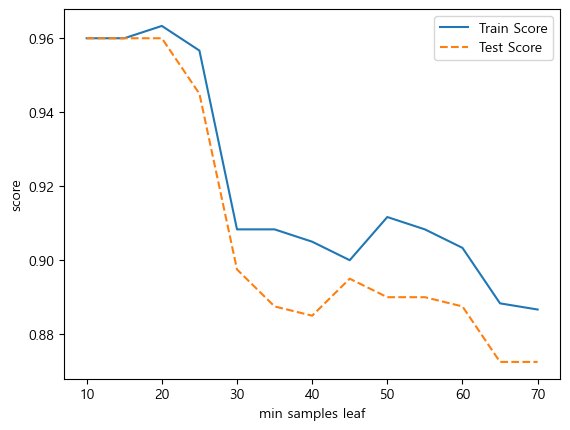

In [76]:
# learning rate별 정확도 그래프 확인
plt.plot(para_leaf, train_score, linestyle='-', label='Train Score')
plt.plot(para_leaf, test_score, linestyle='--', label='Test Score')
plt.ylabel('score')
plt.xlabel('min samples leaf')
plt.legend()
plt.show()

In [77]:
#### min_samples_leaf = 20

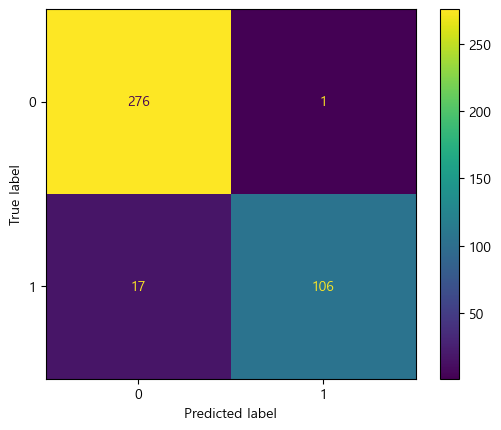

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       277
           1       0.99      0.86      0.92       123

    accuracy                           0.95       400
   macro avg       0.97      0.93      0.95       400
weighted avg       0.96      0.95      0.95       400



In [78]:
# confusion matrix
best_gb = GradientBoostingClassifier(random_state=1986, n_estimators= 30, learning_rate=0.11, 
                                     max_depth=8, min_samples_split=110, min_samples_leaf=20)
best_gb.fit(df_train_x, df_train_y)

y_pred_train=best_gb.predict(df_train_x)
y_prob_train=best_gb.predict_proba(df_train_x)[:,1]
y_pred_test = best_gb.predict(df_test_x)
y_prob_test = best_gb.predict_proba(df_test_x)[:,1]

cm_gb = confusion_matrix(df_test_y, y_pred)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp_gb.plot()
plt.show()

# Classification Report
print(classification_report(df_test_y, y_pred))

In [79]:
train_accuracy = best_gb.score(df_train_x, df_train_y)
print(f"Train Accuracy: {train_accuracy:.4f}")

# 테스트 데이터 정확도
test_accuracy = best_gb.score(df_test_x, df_test_y)
print(f"Test Accuracy: {test_accuracy:.4f}")

Train Accuracy: 0.9633
Test Accuracy: 0.9600


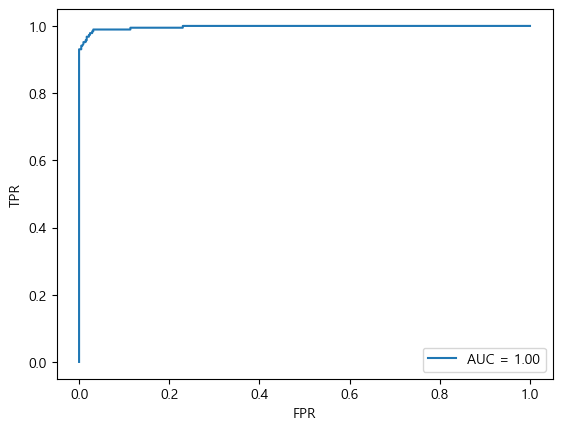

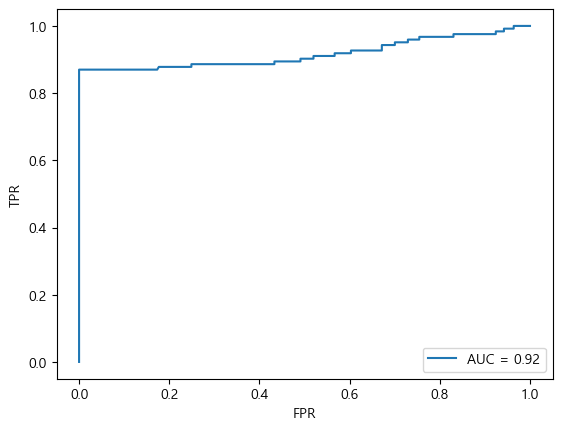

             RF-train   RF-test   RF-diff  GB-train   GB-test   GB-diff
Accuracy     0.868333  0.865000  0.003333  0.963333  0.960000  0.003333
Precision    0.942623  1.000000 -0.057377  1.000000  1.000000  0.000000
Recall       0.614973  0.560976  0.053998  0.882353  0.869919  0.012434
F1_score     0.744337  0.718750  0.025587  0.937500  0.930435  0.007065
Specificity  0.983051  1.000000 -0.016949  1.000000  1.000000  0.000000


In [80]:
metric_list_train = print_metric(df_train_y, y_pred_train,y_prob_train, "GB-train")
metric_list_test = print_metric(df_test_y, y_pred_test, y_prob_test, "GB-test")

metric_df_first['GB-train'] = metric_list_train
metric_df_first['GB-test'] = metric_list_test
metric_df_first['GB-diff'] = metric_df_first['GB-train'] - metric_df_first['GB-test']
print(metric_df_first)

# target(scale)과 관련된 중요인자 확인

##### 1) RandomForest 중요 인자

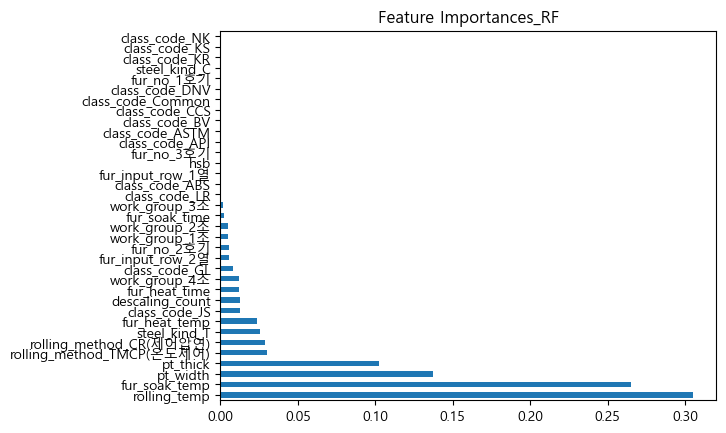

In [81]:
# importances 확인
feat_importances = pd.Series(rf_final.feature_importances_, index=df_train_x.columns)
feat_importances.nlargest(35).plot(kind='barh')
plt.title("Feature Importances_RF")
plt.show()

In [82]:
importance_df_RF = pd.DataFrame({
    'Feature': df_train_x.columns,
    'Importance': rf_final.feature_importances_
})

# 중요도 순으로 내림차순 정렬
importance_df_RF = importance_df_RF.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 상위 35개만 보고 싶을 경우
importance_df_RF.head(35)

,Feature,Importance
0,rolling_temp,0.305019
1,fur_soak_temp,0.264810
2,pt_width,0.137197
3,pt_thick,0.102224
4,rolling_method_TMCP(온도제어),0.029893
5,rolling_method_CR(제어압연),0.028823
6,steel_kind_T,0.025541
7,fur_heat_temp,0.023649
8,class_code_JS,0.012891
9,descaling_count,0.012887


In [83]:
# dummy 변수화 했던 변수들인 다시 원래대로 복구하여 중요도 확인

def extract_base_feature(col_name):
    # 특이한 케이스: '_' 기준으로 쪼갰을 때 무조건 접두사로 인식
    for prefix in ['class_code', 'fur_input_row', 'work_group', 'rolling_method', 'fur_no', 'steel_kind']:
        if col_name.startswith(prefix):
            return prefix
    return col_name  # 예: rolling_temp, pt_width 등

importance_df_RF['group'] = importance_df_RF['Feature'].apply(extract_base_feature)

# 3. 그룹별 importance 합계
grouped_importance_RF = importance_df_RF.groupby('group')['Importance'].sum().sort_values(ascending=False)

# 4. 결과 출력
print(grouped_importance_RF)

group
rolling_temp       0.305019
fur_soak_temp      0.264810
pt_width           0.137197
pt_thick           0.102224
rolling_method     0.058717
steel_kind         0.025541
fur_heat_temp      0.023649
work_group         0.022815
class_code         0.021891
descaling_count    0.012887
fur_heat_time      0.011750
fur_input_row      0.005825
fur_no             0.005259
fur_soak_time      0.002417
hsb                0.000000
Name: Importance, dtype: float64


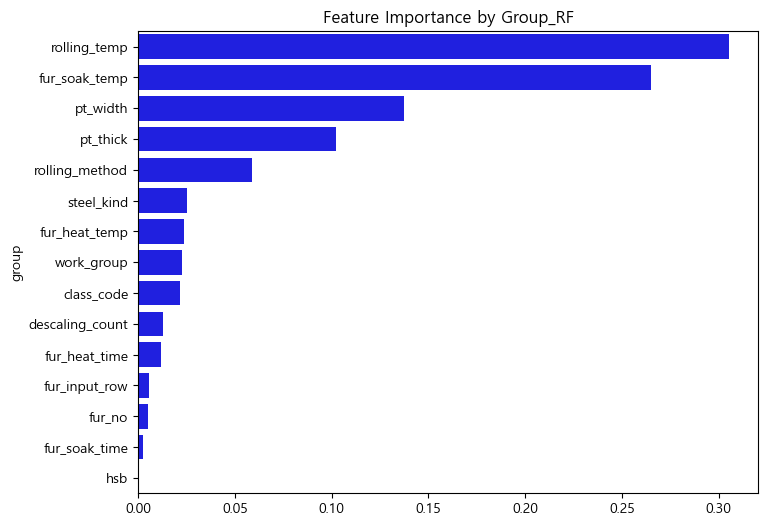

In [84]:
# 그래프로 확인
plt.figure(figsize=(8, 6))
sns.barplot(x=grouped_importance_RF.values, y=grouped_importance_RF.index, color='blue')
plt.title('Feature Importance by Group_RF')
plt.show()

##### 2) Gradient Boosting 중요 인자

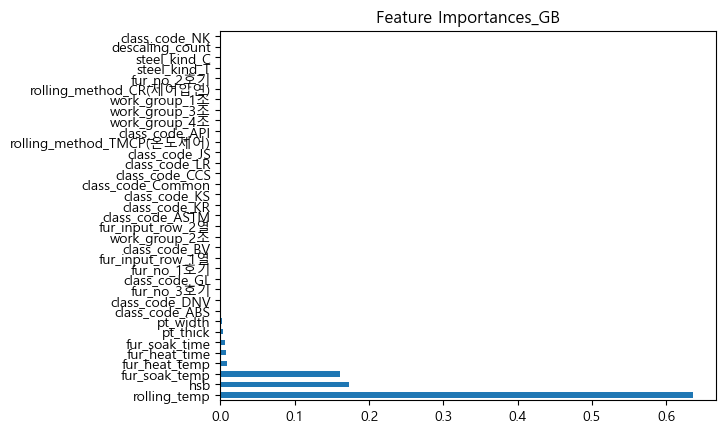

In [85]:
# importances 확인
feat_importances = pd.Series(best_gb.feature_importances_, index=df_train_x.columns)
feat_importances.nlargest(35).plot(kind='barh')
plt.title("Feature Importances_GB")
plt.show()

In [86]:
importance_df_GB = pd.DataFrame({
    'Feature': df_train_x.columns,
    'Importance': best_gb.feature_importances_
})

# 중요도 순으로 내림차순 정렬
importance_df_GB = importance_df_GB.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# 상위 35개만 보고 싶을 경우
importance_df_GB.head(35)

,Feature,Importance
0,rolling_temp,6.358138e-01
1,hsb,1.728059e-01
2,fur_soak_temp,1.604299e-01
3,fur_heat_temp,8.511195e-03
4,fur_heat_time,7.404902e-03
5,fur_soak_time,6.350135e-03
6,pt_thick,3.295776e-03
7,pt_width,2.181116e-03
8,class_code_ABS,8.208583e-04
9,class_code_DNV,5.578712e-04


In [87]:
# dummy 변수화 했던 변수들인 다시 원래대로 복구하여 중요도 확인

def extract_base_feature(col_name):
    # 특이한 케이스: '_' 기준으로 쪼갰을 때 무조건 접두사로 인식
    for prefix in ['class_code', 'fur_input_row', 'work_group', 'rolling_method', 'fur_no', 'steel_kind']:
        if col_name.startswith(prefix):
            return prefix
    return col_name  # 예: rolling_temp, pt_width 등

importance_df_GB['group'] = importance_df_GB['Feature'].apply(extract_base_feature)

# 3. 그룹별 importance 합계
grouped_importance_GB = importance_df_GB.groupby('group')['Importance'].sum().sort_values(ascending=False)

# 4. 결과 출력
print(grouped_importance_GB)

group
rolling_temp       0.635814
hsb                0.172806
fur_soak_temp      0.160430
fur_heat_temp      0.008511
fur_heat_time      0.007405
fur_soak_time      0.006350
pt_thick           0.003296
pt_width           0.002181
class_code         0.002022
fur_no             0.000805
fur_input_row      0.000260
work_group         0.000120
descaling_count    0.000000
rolling_method     0.000000
steel_kind         0.000000
Name: Importance, dtype: float64


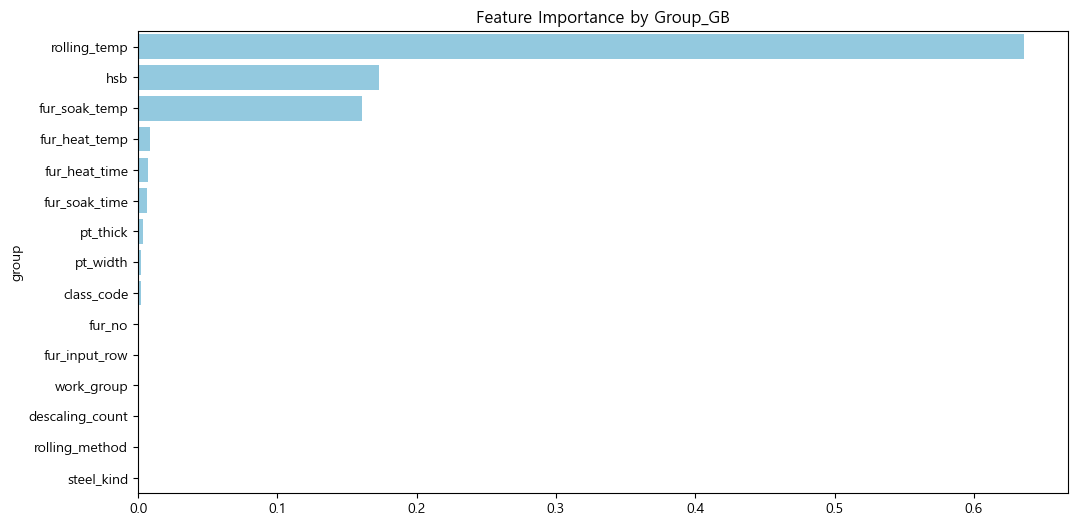

In [88]:
# 그래프로 확인
plt.figure(figsize=(12, 6))
sns.barplot(x=grouped_importance_GB.values, y=grouped_importance_GB.index, color='skyblue')
plt.title('Feature Importance by Group_GB')
plt.show()

#### => RF와 GB를 통해 features의 importance를 확인 
- rolling_temp
- fur_soak_temp
- class_code
- fur_heat_time
- fur_heat_temp
- fur_soak_time
- pt_width
- work_gruop
- pt_thick
- rolling_method
- steel_kind

##### hsb, fur_no, fur_input_row, descailing_count

## Importance를 고려하여 data frame 재구성
-> 데이터 전처리에서 재구성함

# 재구성 데이터 기준으로 2차모델

In [89]:
df_raw=pd.read_csv('./B1_종합실습2_전처리데이터(2차_tree).csv')
df_raw.head()

,scale,pt_thick,pt_width,fur_heat_temp,fur_heat_time,fur_soak_temp,fur_soak_time,rolling_temp,steel_kind_C,steel_kind_T,...,class_code_BV,class_code_CCS,class_code_Common,class_code_DNV,class_code_GL,class_code_JS,class_code_KR,class_code_KS,class_code_LR,class_code_NK
0,0,32,3700,1144,116,1133,59,934,0,1,...,0,0,0,0,0,0,0,0,0,0
1,0,32,3700,1144,122,1135,53,937,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,33,3600,1129,116,1121,55,889,0,1,...,0,0,0,1,0,0,0,0,0,0
3,0,33,3600,1152,125,1127,68,885,0,1,...,0,0,0,1,0,0,0,0,0,0
4,0,38,3100,1140,134,1128,48,873,0,1,...,1,0,0,0,0,0,0,0,0,0


In [90]:
# 목표변수, 설명변수 데이터 지정
df_raw_y = df_raw['scale']
df_raw_x = df_raw.drop('scale', axis = 1, inplace = False)
df_raw_x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   pt_thick                   1000 non-null   int64
 1   pt_width                   1000 non-null   int64
 2   fur_heat_temp              1000 non-null   int64
 3   fur_heat_time              1000 non-null   int64
 4   fur_soak_temp              1000 non-null   int64
 5   fur_soak_time              1000 non-null   int64
 6   rolling_temp               1000 non-null   int64
 7   steel_kind_C               1000 non-null   int64
 8   steel_kind_T               1000 non-null   int64
 9   rolling_method_CR(제어압연)    1000 non-null   int64
 10  rolling_method_TMCP(온도제어)  1000 non-null   int64
 11  work_group_1조              1000 non-null   int64
 12  work_group_2조              1000 non-null   int64
 13  work_group_3조              1000 non-null   int64
 14  work_group_4조            

In [91]:
df_train_x, df_test_x, df_train_y, df_test_y = train_test_split(df_raw_x, df_raw_y, test_size = 0.4, random_state = 1986)
print("train data X size : {}".format(df_train_x.shape))
print("train data Y size : {}".format(df_train_y.shape))
print("test data X size : {}".format(df_test_x.shape))
print("test data Y size : {}".format(df_test_y.shape))

train data X size : (600, 28)
train data Y size : (600,)
test data X size : (400, 28)
test data Y size : (400,)


# 분류 모델 고고
## -Random Forest
- estimator = 8
- leaf_data = 17
- sample data = 57
- max depth = 5

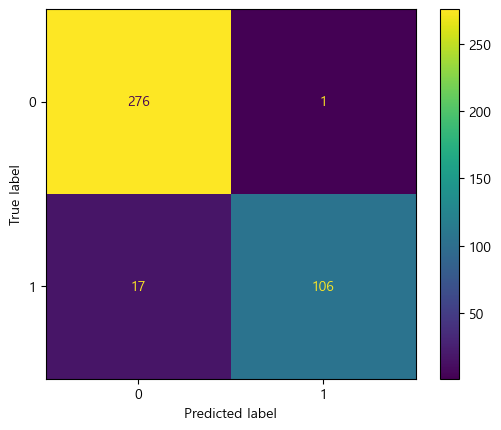

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       277
           1       0.99      0.86      0.92       123

    accuracy                           0.95       400
   macro avg       0.97      0.93      0.95       400
weighted avg       0.96      0.95      0.95       400



In [94]:
# 평가
rf_final.fit(df_train_x, df_train_y)
y_pred_train = rf_final.predict(df_train_x)
y_prob_train = rf_final.predict_proba(df_train_x)[:,1]
y_pred_test = rf_final.predict(df_test_x)
y_prob_test = rf_final.predict_proba(df_test_x)[:,1]


# confusion matrix
cm = confusion_matrix(df_test_y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

print(classification_report(df_test_y, y_pred))


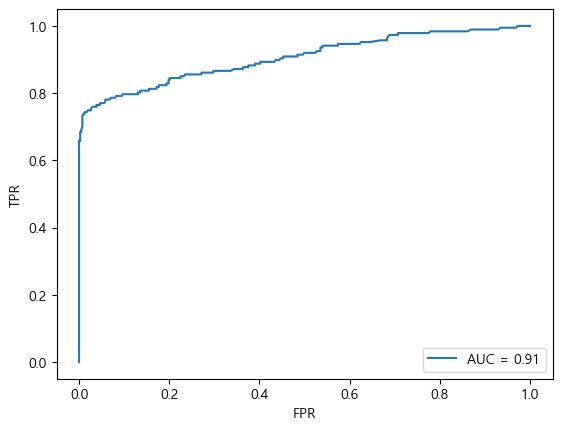

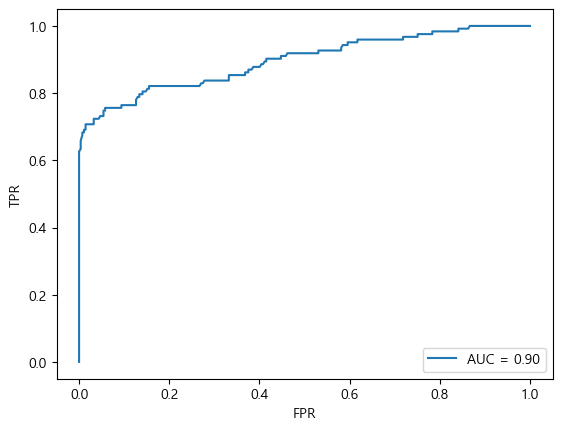

             RF-train   RF-test   RF-diff
Accuracy     0.881667  0.867500  0.014167
Precision    1.000000  1.000000  0.000000
Recall       0.620321  0.569106  0.051215
F1_score     0.765677  0.725389  0.040288
Specificity  1.000000  1.000000  0.000000


In [96]:
metric_df_second = pd.DataFrame(index=['Accuracy', 'Precision', 'Recall', 'F1_score', 'Specificity'])
metric_list_train = print_metric(df_train_y, y_pred_train,y_prob_train, "RF-train")
metric_list_test = print_metric(df_test_y, y_pred_test, y_prob_test, "RF-test")

metric_df_second['RF-train'] = metric_list_train
metric_df_second['RF-test'] = metric_list_test
metric_df_second['RF-diff'] = metric_df_second['RF-train']-metric_df_second['RF-test']
print(metric_df_second)

## -Gradient Boosting
- learning rate = 2.7
- estimator = 61

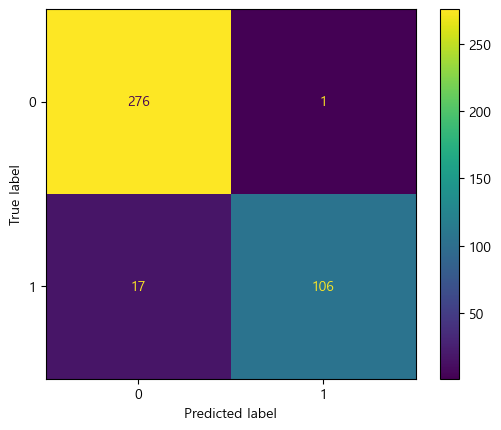

In [98]:
best_gb.fit(df_train_x, df_train_y)

y_pred_train=best_gb.predict(df_train_x)
y_prob_train=best_gb.predict_proba(df_train_x)[:,1]
y_pred_test = best_gb.predict(df_test_x)
y_prob_test = best_gb.predict_proba(df_test_x)[:,1]

cm_gb = confusion_matrix(df_test_y, y_pred)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp_gb.plot()
plt.show()

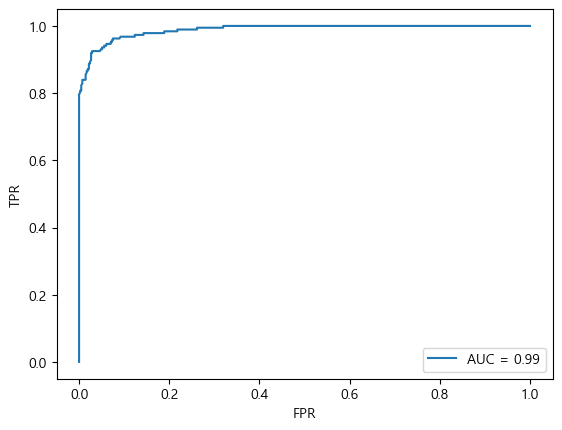

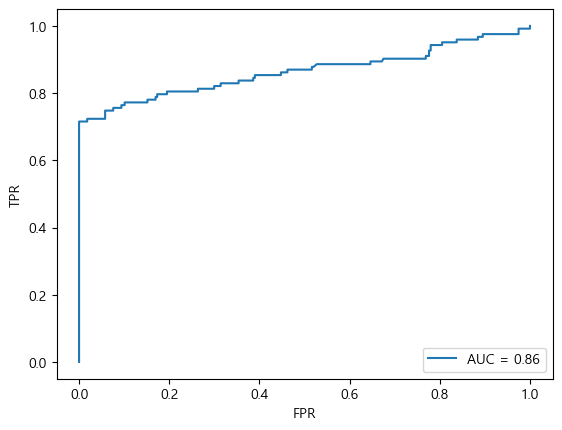

             RF-train   RF-test   RF-diff  GB-train   GB-test   GB-diff
Accuracy     0.881667  0.867500  0.014167  0.923333  0.910000  0.013333
Precision    1.000000  1.000000  0.000000  1.000000  0.988764  0.011236
Recall       0.620321  0.569106  0.051215  0.754011  0.715447  0.038564
F1_score     0.765677  0.725389  0.040288  0.859756  0.830189  0.029567
Specificity  1.000000  1.000000  0.000000  1.000000  0.996390  0.003610


In [99]:
metric_list_train = print_metric(df_train_y, y_pred_train,y_prob_train, "GB-train")
metric_list_test = print_metric(df_test_y, y_pred_test, y_prob_test, "GB-test")

metric_df_second['GB-train'] = metric_list_train
metric_df_second['GB-test'] = metric_list_test
metric_df_second['GB-diff'] = metric_df_second['GB-train']-metric_df_second['GB-test']
print(metric_df_second)

In [100]:
print("1차 모델")
display(metric_df_first)
print("2차 모델")
display(metric_df_second)

1차 모델


,RF-train,RF-test,RF-diff,GB-train,GB-test,GB-diff
Accuracy,0.868333,0.865000,0.003333,0.963333,0.960000,0.003333
Precision,0.942623,1.000000,-0.057377,1.000000,1.000000,0.000000
Recall,0.614973,0.560976,0.053998,0.882353,0.869919,0.012434
F1_score,0.744337,0.718750,0.025587,0.937500,0.930435,0.007065
Specificity,0.983051,1.000000,-0.016949,1.000000,1.000000,0.000000


2차 모델


,RF-train,RF-test,RF-diff,GB-train,GB-test,GB-diff
Accuracy,0.881667,0.867500,0.014167,0.923333,0.910000,0.013333
Precision,1.000000,1.000000,0.000000,1.000000,0.988764,0.011236
Recall,0.620321,0.569106,0.051215,0.754011,0.715447,0.038564
F1_score,0.765677,0.725389,0.040288,0.859756,0.830189,0.029567
Specificity,1.000000,1.000000,0.000000,1.000000,0.996390,0.003610
